# Household / hobby service-scope benchmark

## tl;dr

Fresh93: Jev 41/93 (44.1%); Luna 41/93 (44.1%). Median request-time sums: 0.645s / 4.510s. Usage-based cost estimates: $0.022580 / $0.052664.

Results below compare **original greedy Jev and original greedy GPT-6 Luna only**. Expanded-path Jev and hybrid retrieval are abandoned and excluded. Scope selection is a product-use decision, not a filter for correct predictions. Historical full94, historical in-scope78, and fresh93 are separate groups; do not combine them as one blind test.

## Context & Methods

Scope policy was recorded before fresh inference. Household goods, kitchen, clothing/accessories, toys/games, hobby/sports, personal electronics/parts and DIY tools are candidates. Automotive, generic electronic/industrial supplies, professional machinery/stage/medical equipment are excluded. This is an unverified service-policy draft, not a verified Sazo rule or importability decision.

The automated screen yields 582 candidate products. Manual review of initial 96 fresh plus 80 historical cases excludes 5 factually out-of-scope products; fresh93 and historical78 remain. Rejected sampled products are **not replaced**. Remaining rule-eligible pool 577 is not a fully manually reviewed service catalogue.

### Key assumptions

Personal use is inferred from product facts, not verified buyer intent. Mixed materials, sets, missing or conflicting details remain. Fresh IDs have not appeared in earlier inference; product facts are inspected for scope review before inference, but labels and predictions are not used for selection. Sampling uses a fixed hash and category-balanced round-robin, so sample frequencies do not represent actual marketplace traffic.

Both providers receive identical title/attributes/category and full local HS2022 options at HS2 → HS4 → HS6. Single top-1 branch, no added research, no image evidence, no candidate reranking. GPT-6 Luna reasoning low. Providers run concurrently per product, ordered by fixed random seed. Time includes sequential HTTP, parsing and validation; excludes collection, queues and total application latency. Usage-based USD estimates are not invoices; more abstentions can lower cost/time. Accuracy denominator includes abstentions and errors.

Source: [HSCodeComp](https://huggingface.co/datasets/ATH-MaaS/HSCodeComp). Expert US code reference truncated to HS6; not a verified Korean customs ruling. The original 94-case experiment remains intact.

## Data

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
p=Path('service-scope-results-2026-10-07.json')
if not p.exists():p=Path('product-catalog/notebooks')/p
report=json.loads(p.read_text())
results=pd.DataFrame(report['results'])
selection=report['selection']
print({k:selection[k] for k in ['all_source_cases','eligible_cases','excluded_cases','fresh_pool']})
print('Initial fresh sample:',len(selection['initial_fresh_ids']),'final fresh sample:',len(selection['fresh_ids']))
print('Historical in-scope:',len(selection['observed_ids']))
display(pd.DataFrame(selection['fresh_categories'].items(),columns=['category','final_category_count']))
print('Actual new run:',report['actual_new_run'])

{'all_source_cases': 632, 'eligible_cases': 577, 'excluded_cases': 55, 'fresh_pool': 499}
Initial fresh sample: 96 final fresh sample: 93
Historical in-scope: 78


,category,final_category_count
0,Computer & Office,4
1,Home Appliances,4
2,Jewelry & Accessories,4
3,Toys & Hobbies,4
4,Luggage & Bags,4
5,Weddings & Events,2
6,Tools,4
7,Men's Clothing,4
8,Shoes,4
9,Apparel Accessories,5


Actual new run: {'calls': 528, 'estimated_cost_usd': 0.07524420500000001, 'ledger_calls': 528, 'ledger_known_cost': 0.07524420500000001, 'ledger_unknown_cost_calls': 0, 'validation_failures': 0}


## Results

Historical subgroup figures are descriptive reuse of previously observed outputs. Primary new comparison is the fresh93 group. Answered accuracy and coverage appear beside full-denominator exact HS6 accuracy.

In [2]:
rows=[]
for group,values in report['groups'].items():
    for provider,s in values.items():
        q=s['quality']
        rows.append({'group':group,'provider':provider,'cases':s['cases'],'correct':q['correct_hs6'],
          'accuracy':q['accuracy_all'],'answered_accuracy':q['accuracy_answered'],'answer_rate':q['coverage'],
          'median_s':s['workflow_p50_ms']/1000,'p95_s':s['workflow_p95_ms']/1000,
          'calls':s['calls'],'input_tokens':s['input_tokens'],'output_tokens':s['output_tokens'],
          'cost_USD':s['estimated_cost_usd'],'errors':s['errors']})
comparison=pd.DataFrame(rows)
display(comparison.round(4))
print('Fresh paired comparison:',report['paired_fresh'])

,group,provider,cases,correct,accuracy,answered_accuracy,answer_rate,median_s,p95_s,calls,input_tokens,output_tokens,cost_USD,errors
0,historical_full94,jev,94,28,0.2979,0.3457,0.8617,0.6748,0.8476,275,558238,112024,0.0234,0
1,historical_full94,llm,94,36,0.3830,0.5538,0.6915,4.2965,6.2875,261,394622,13961,0.0545,0
2,historical_scope78,jev,78,26,0.3333,0.3881,0.8590,0.6741,0.8443,229,463156,92140,0.0195,0
3,historical_scope78,llm,78,33,0.4231,0.6000,0.7051,4.3063,6.5208,218,324596,11929,0.0450,0
4,fresh_scope93,jev,93,41,0.4409,0.5125,0.8602,0.6450,0.8293,272,537615,107094,0.0226,0
5,fresh_scope93,llm,93,41,0.4409,0.6833,0.6452,4.5105,7.6085,256,377590,14705,0.0527,0


Fresh paired comparison: {'accuracy_difference_jev_minus_llm': 0.0, 'difference_95pct_paired_bootstrap': [-0.0967741935483871, 0.0967741935483871], 'jev_only_correct': 10, 'llm_only_correct': 10, 'both_correct': 31, 'both_incorrect': 42, 'uncertainty': 'Paired 20000-bootstrap, seed42; descriptive for this category-balanced sample, not service-population uncertainty or proof of equivalence'}


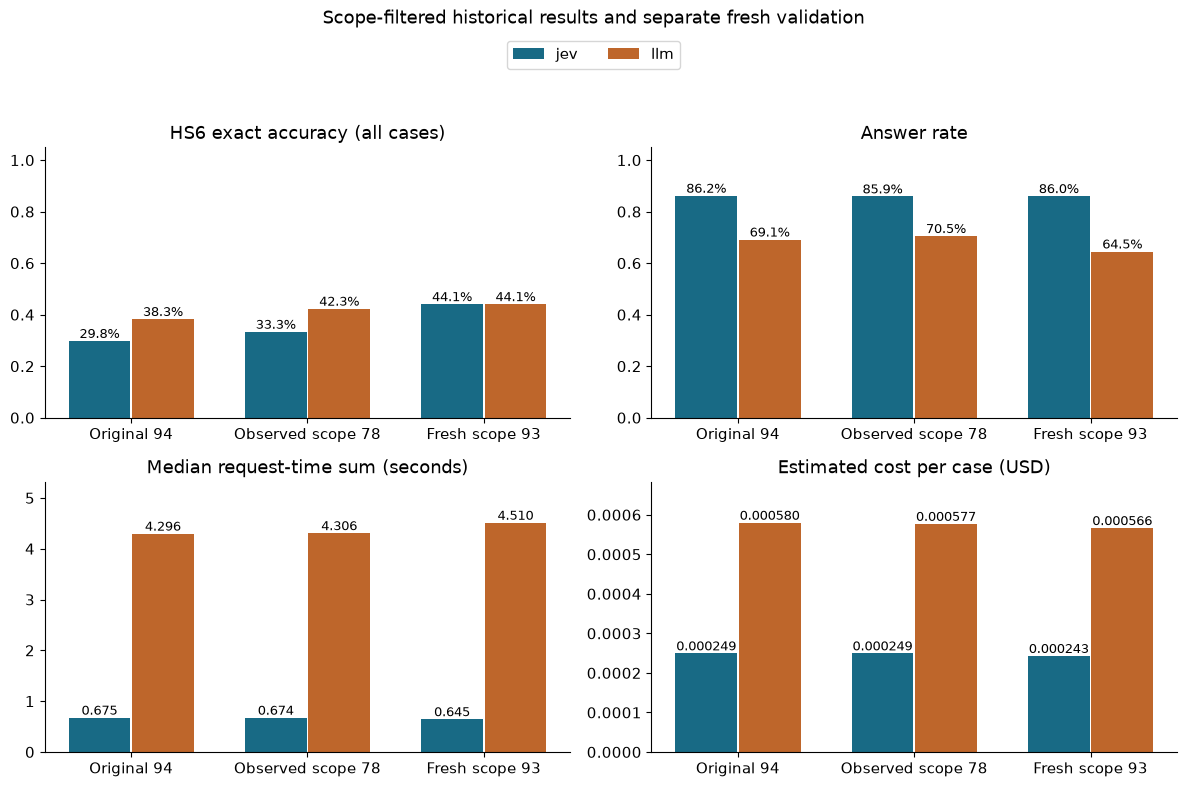

In [3]:
plt.rcParams.update({'font.size':11,'axes.spines.top':False,'axes.spines.right':False})
fig,grid=plt.subplots(2,2,figsize=(12,8));axes=grid.ravel()
comparison['cost_per_case_USD']=comparison.cost_USD/comparison.cases
groups=['historical_full94','historical_scope78','fresh_scope93']
labels=['Original 94','Observed scope 78','Fresh scope 93']
colors={'jev':'#186A85','llm':'#BE662B'}
for p,offset in [('jev',-.18),('llm',.18)]:
    rs=comparison[comparison.provider.eq(p)].set_index('group').reindex(groups)
    for ax,col,title in zip(axes,['accuracy','answer_rate','median_s','cost_per_case_USD'],['HS6 exact accuracy (all cases)','Answer rate','Median request-time sum (seconds)','Estimated cost per case (USD)']):
        bars=ax.bar([i+offset for i in range(3)],rs[col],width=.35,label=p,color=colors[p])
        for bar,val in zip(bars,rs[col]):ax.annotate(f'{val:.1%}' if col in ('accuracy','answer_rate') else (f'{val:.3f}' if col=='median_s' else f'{val:.6f}'),(bar.get_x()+bar.get_width()/2,val),ha='center',va='bottom',fontsize=9)
        ax.set_title(title);ax.set_xticks(range(3),labels);ax.set_ylim(bottom=0)
        if col in ('accuracy','answer_rate'):ax.set_ylim(0,1.05)
axes[2].set_ylim(0,comparison.median_s.max()*1.18)
axes[3].set_ylim(0,comparison.cost_per_case_USD.max()*1.18)
handles,names=axes[0].get_legend_handles_labels()
fig.legend(handles,names,loc='upper center',bbox_to_anchor=(.5,.95),ncol=2)
fig.suptitle('Scope-filtered historical results and separate fresh validation')
fig.tight_layout(rect=[0,0,1,.9]);fig.savefig('service-scope-comparison.png',dpi=150,bbox_inches='tight');plt.show()

In [4]:
fresh=results[results.group.eq('fresh_scope93')].copy()
# Per-category diagnostics, never used to remove difficult categories after inference.
display(fresh.groupby(['top_category','provider']).correct.agg(cases='size',correct='sum').reset_index())
# Exact-case disagreements, including abstentions; full outputs remain in JSON.
display(fresh[['id','provider','reference_hs6','hs6','status','correct']].head(24))
print('Sample-specific accuracy intervals:',{p:report['groups']['fresh_scope93'][p]['accuracy_95pct_wilson'] for p in ['jev','llm']})

,top_category,provider,cases,correct
0,Apparel Accessories,jev,5,3
1,Apparel Accessories,llm,5,3
2,Beauty & Health,jev,3,1
3,Beauty & Health,llm,3,1
4,Computer & Office,jev,4,2
5,Computer & Office,llm,4,1
6,Consumer Electronics,jev,4,0
7,Consumer Electronics,llm,4,0
8,Furniture,jev,4,1
9,Furniture,llm,4,2


,id,provider,reference_hs6,hs6,status,correct
344,hscodecomp-0022,jev,854231,854231,candidate,True
345,hscodecomp-0033,jev,851030,851030,candidate,True
346,hscodecomp-0056,jev,711620,711711,candidate,False
347,hscodecomp-0072,jev,950300,950300,candidate,True
348,hscodecomp-0076,jev,420222,420221,candidate,False
349,hscodecomp-0078,jev,620444,NaN,needs_information,False
350,hscodecomp-0082,jev,820559,820559,candidate,True
351,hscodecomp-0091,jev,821192,821192,candidate,True
352,hscodecomp-0108,jev,610342,620342,candidate,False
353,hscodecomp-0111,jev,621132,620520,candidate,False


Sample-specific accuracy intervals: {'jev': [0.34429385129378526, 0.5421184339613663], 'llm': [0.34429385129378526, 0.5421184339613663]}


## Takeaways

Read the executed fresh results as this sample's measured comparison, not proof of equivalent accuracy or readiness for automatic final customs classification. A narrowed domain can change difficulty but is not itself a model improvement. The observed historical subset was inspected previously and cannot serve as blind validation. Keep full94 results alongside service-scope results when revising the report or slides.

This notebook makes no API calls. `prepare_service_scope.py` reproduces input-only selection and its audit; `run_service_scope.py --live` explicitly runs the fixed original greedy comparison; `report_service_scope.py` regenerates this notebook from local run records. Labels and provider journals are never included in requests. Difficult in-scope cases remain in the denominator.

Fresh93: Jev 41/93 (44.1%); Luna 41/93 (44.1%). Median request-time sums: 0.645s / 4.510s. Usage-based cost estimates: $0.022580 / $0.052664.

Accuracy difference (Jev minus Luna), paired sample-specific 95% bootstrap interval: [-0.0967741935483871, 0.0967741935483871]. No equivalence or non-inferiority margin was pre-specified, so do not claim equivalent accuracy from this pilot alone. Jev answered 80 cases, Luna 60; answered accuracy was 51.3% versus 68.3%. Equal correct counts do not imply equal false-answer risk. Historical in-scope78 also remained worse for Jev (33.3%) than Luna (42.3%), so scope restriction alone does not establish general quality preservation.